# 10 — Solve the credit-supply transition (flexible exchange rate, foreign-currency debt)

**Ports**: `Code/MATLAB/Transition/solve_transition_bis.m` (`else` / flexible branch) and `Code/MATLAB/Transition/backsolve_egm.m`.

**What we compute**: the perfect-foresight transition path between the **initial** SS (`BGss=0`, notebook 09) and the **final** SS (`BGss = shock_b_agg[-1] ≈ -11.13`, notebook 09), driven by the AR(1) credit-supply path `shock_b_agg` (notebook 03). Households know the entire price path and play their lifetime problem accordingly. The system is solved at the **calibrated** $\beta^\star$.

**Unknowns**: `XX = [k_agg(2..TT); lab_agg(1..TT)]` of length $2\,TT-1 = 399$. Each entry is required to satisfy:
* capital market: $k'(t) = a_\text{prime}(t)/q(t) - \text{shock\_b\_agg}(t)$ for $t=1..TT-1$;
* labour-Euler: $l_\text{prime}(t) = (1-\omega)(\varepsilon_w-1)/\varepsilon_w \cdot w(t) / [c(t)\,\chi_\text{dis}]$ for $t=1..TT$.

**Strategy**:
1. Load MATLAB's converged warm start `Code/MATLAB/transition_start.mat` (200-period path of `kl_path`).
2. Evaluate residual at the warm start. We expect $\le 10^{-3}$ since this path was already converged in MATLAB.
3. **Optional** (gated behind `REFINE = True`): run `scipy.optimize.fsolve` to drive $\|r\|_\infty \le 10^{-12}$. Costs ~2–3 minutes.
4. Save `tot, k_agg, lab_agg, y_agg, c_t, r_t, w_r, q_agg, ...` to `../output/transition_flex.npz` for notebook 11.

**Foreign-currency debt revaluation at $t=1$**: the initial period applies the MATLAB `foreign==True` branch in `backsolve_egm.m` lines 124–153: gross liabilities `Bgrid_fine` get revalued by `1/(tot[0]/tot_initial)` before the distribution evolves. With our SS-to-SS setup `BG_shock=0` and `lev_rat_rich=1`, this only redistributes mass for borrowing-constrained households.

**MATLAB references** (line numbers refer to `Code/MATLAB/Transition/`):
* `solve_transition_bis.m` lines 1–34 (production block, paths)
* `solve_transition_bis.m` lines 124–157 (else branch: 1-D `tot` solve per period)
* `backsolve_egm.m` lines 1–197 (backward EGM + forward distribution)

## Imports + load Phase B/C output and MATLAB warm start

In [1]:
from pathlib import Path
import time

import numpy as np
from scipy.optimize import brentq, fsolve
from scipy.interpolate import PchipInterpolator
from scipy.io import loadmat

OUTPUT_DIR = Path('..') / 'output'
MATLAB_DIR = Path('..') / '..' / 'MATLAB'

p   = np.load(OUTPUT_DIR / 'params.npz')
cb  = np.load(OUTPUT_DIR / 'calibration.npz')
sh  = np.load(OUTPUT_DIR / 'shock_path.npz')
ini = np.load(OUTPUT_DIR / 'initial_ss.npz')

# Grids and parameters
Agrid = p['params__Agrid']
Agrid_fine = p['params__Agrid_fine']
piex = p['params__piex']
ex = p['params__ex']
nA = int(p['params__nA'])
nA_fine = int(p['params__nA_fine'])
ns = int(p['params__ns'])
Index_b_min = int(p['params__Index_b_min'])
bmin = float(p['params__bmin'])
Amax = float(p['params__Amax'])
y_ss = float(p['params__y_ss'])
k_ss = float(p['params__k_ss'])
b_agg_ss = float(p['params__b_agg_ss'])
r_ss = float(p['params__r_ss'])
w_ss = float(p['params__w_ss'])
delta = float(p['params__delta'])
alpha = float(p['params__alpha'])
gamma = float(p['params__gamma'])
theta = float(p['params__theta'])
omega = float(p['params__omega'])
varphi = float(p['params__varphi'])
chi_dis = float(p['params__chi_dis'])
epsilon_f = float(p['params__epsilon_f'])
epsilon_w = float(p['params__epsilon_w'])
z_ss = float(p['params__z_ss'])
ex_mean = float(p['params__ex_mean'])

beta_calibrated = float(cb['beta_calibrated'])
shock_b_agg = sh['shock_b_agg']
TT = int(sh['TT'])

# Initial SS (transition starting point)
k_initial = float(ini['k_initial'])
l_initial = float(ini['l_initial'])
T_initial = float(ini['T_initial'])
G0_initial = ini['G0_initial']
d_s = float(ini['d_s'])
theta_star = int(ini['theta_star'])

# Final SS (transition end-of-rope; provides terminal policy functions)
k_final = float(ini['k_final'])
l_final = float(ini['l_final'])
T_final = float(ini['T_final'])
cpol_final = ini['cpol_final']
c_fine_final = ini['c_fine_final']

# Transition extras (Main.m line 312, MIT_transition.m lines 88-96)
phi_ac = 17.0
foreign = True
BG_shock = 0.0           # SS-to-SS: no balance-sheet shock at t=1
q_initial = 1.0
tot_initial = T_initial
k_const_hat = 0.0
k_const = 0.0
z_t = np.ones(TT) * z_ss

# MATLAB warm start (already-converged 200-period path from a prior MATLAB solve)
mat = loadmat(MATLAB_DIR / 'transition_start.mat')
kl_path = np.asarray(mat['kl_path']).flatten()
assert kl_path.size == 2 * TT - 1, f'kl_path size {kl_path.size} != 2*TT-1 = {2*TT-1}'

print(f'TT          = {TT}')
print(f'k_initial   = {k_initial:.6f}, k_final = {k_final:.6f}')
print(f'l_initial   = {l_initial:.6f}, l_final = {l_final:.6f}')
print(f'T_initial   = {T_initial:.6f}, T_final = {T_final:.6f}')
print(f'shock_b_agg[0]  = {shock_b_agg[0]:.4f},  shock_b_agg[-1] = {shock_b_agg[-1]:.4f}')
print(f'kl_path     shape = {kl_path.shape}')
print(f'beta_calibrated = {beta_calibrated:.6f},  phi_ac = {phi_ac}')
print(f'd_s = {d_s:.6f},  theta_star = {theta_star}')

TT          = 200
k_initial   = 28.314968, k_final = 32.266065
l_initial   = 0.984138, l_final = 1.022279
T_initial   = 1.016509, T_final = 0.978861
shock_b_agg[0]  = -0.2266,  shock_b_agg[-1] = -11.1321
kl_path     shape = (399,)
beta_calibrated = 0.983225,  phi_ac = 17.0
d_s = 1.014945,  theta_star = 3


## Helpers

In [2]:
def basefun_vec(grid, x):
    n = grid.size
    ind1 = np.searchsorted(grid, x, side='right') - 1
    ind1 = np.clip(ind1, 0, n - 2)
    ind2 = ind1 + 1
    w2 = (x - grid[ind1]) / (grid[ind2] - grid[ind1])
    w2 = np.clip(w2, 0.0, 1.0)
    w1 = 1.0 - w2
    return ind1, ind2, w1, w2

## Port of `backsolve_egm.m`

Two passes:
1. **Backward EGM** for $t=TT-1, TT-2, ..., 1$: given next-period consumption policy, run one EGM step with prices $(r_t, \text{tot}_t, y_t, \Pi_t, \Pi_t^I)$.
2. **Forward distribution simulation** for $t=1..TT-1$: starting from `dist_tran(:,:,1) = G0_initial` (with revaluation if `foreign`), march the joint distribution forward using `dec_tran_fine[:,:,t-1]` and `piex`.

In [3]:
def backsolve_egm(r_t, t_guess, y_agg, cpol, c_fine, prof_firm, Profit_i, G0):
    sav_grid = np.tile(Agrid[:, None], (1, ns))
    exLw = np.tile(ex[None, :], (nA, 1))

    # Decompose A into (K, B): with k_const_hat=0 and BG_shock=0, lev_rat_rich = 1,
    # so K = max(a, 0) and B = min(a, 0). Only borrowers carry the debt that gets revalued.
    pos = Agrid_fine > 0
    net_a_rich = (G0[pos, :].sum(axis=1) * Agrid_fine[pos]).sum()
    lev_rat_rich = (1.0 - k_const_hat) * k_initial * q_initial / max(net_a_rich, 1e-12)
    if BG_shock == 0:
        lev_rat_rich = 1.0
    Kgrid_fine = np.maximum(lev_rat_rich * Agrid_fine + k_const, 0.0)
    Bgrid_fine = -(Kgrid_fine - Agrid_fine)

    c_tran = np.full((nA, ns, TT), np.nan)
    c_tran_fine_out = np.full((nA_fine, ns, TT), np.nan)
    dec_tran = np.full((nA, ns, TT), np.nan)
    dec_tran_fine = np.full((nA_fine, ns, TT), np.nan)
    c_tran[:, :, TT - 1] = cpol
    c_tran_fine_out[:, :, TT - 1] = c_fine

    for t in range(TT - 2, -1, -1):
        r = r_t[t + 1]
        r_yesterday = r_t[t]
        tot_t = t_guess[t]
        y_t_agg = y_agg[t]
        prof_firms_t = prof_firm[t] + Profit_i[t]
        mult = 1.0 + tot_t ** (theta - 1.0) * omega / (1.0 - omega)

        # Constrained consumption (stuck at bmin)
        c_constrained = np.maximum(
            (1.0 / mult) * (
                (1.0 + r_yesterday) * sav_grid
                + (epsilon_f - 1.0) / epsilon_f * exLw * y_t_agg * (1.0 - alpha) / ex_mean
                + prof_firms_t - bmin
            ),
            1e-5,
        )

        Emup1 = c_tran[:, :, t + 1] ** (-gamma)
        Emup = beta_calibrated * (1.0 + r) * (Emup1 @ piex.T)
        c_s = Emup ** (-1.0 / gamma)

        a_today = (
            c_s * mult + sav_grid
            - (epsilon_f - 1.0) / epsilon_f * exLw * y_t_agg * (1.0 - alpha) / ex_mean
            - prof_firms_t
        ) / (1.0 + r_yesterday)

        c_new = np.empty((nA, ns))
        c_new_fine = np.empty((nA_fine, ns))
        dec_temp_fine = np.empty((nA_fine, ns))
        for j in range(ns):
            xj = a_today[:, j]
            cj = c_s[:, j]
            threshold = a_today[Index_b_min, j]
            mask = Agrid > threshold
            interp = PchipInterpolator(xj, cj, extrapolate=True)
            c_new[:, j] = np.where(mask, interp(Agrid), c_constrained[:, j])
            c_new[:, j] = np.maximum(c_new[:, j], 1e-5)

            mask_fine = Agrid_fine > threshold
            interp_unc = PchipInterpolator(xj, cj, extrapolate=True)
            interp_con = PchipInterpolator(Agrid, c_constrained[:, j], extrapolate=True)
            c_new_fine[:, j] = np.where(
                mask_fine, interp_unc(Agrid_fine), interp_con(Agrid_fine),
            )
            dec_unc = (
                (1.0 + r_yesterday) * Agrid_fine
                + (epsilon_f - 1.0) / epsilon_f * ex[j] * y_t_agg * (1.0 - alpha) / ex_mean
                + prof_firms_t
                - c_new_fine[:, j] * mult
            )
            dec_temp_fine[:, j] = np.where(mask_fine, dec_unc, bmin)

        c_tran[:, :, t] = c_new
        dec_tran[:, :, t] = (
            (1.0 + r_yesterday) * sav_grid
            + (epsilon_f - 1.0) / epsilon_f * exLw * y_t_agg * (1.0 - alpha) / ex_mean
            + prof_firms_t - c_new * mult
        )
        if dec_temp_fine.min() < bmin - 1e-10:
            raise RuntimeError(f'dec_temp_fine < bmin at t={t}')
        c_tran_fine_out[:, :, t] = c_new_fine
        dec_tran_fine[:, :, t] = dec_temp_fine

    # ---------- Forward distribution simulation ----------
    dist_tran = np.zeros((nA_fine, ns, TT))
    if foreign:
        Bgrid_fine_new = Bgrid_fine / (t_guess[0] / tot_initial)
        A_grid_fine_new = Bgrid_fine_new + Kgrid_fine
        if bmin / t_guess[0] < Agrid_fine[0]:
            raise RuntimeError('positive mass would land outside Agrid_fine')
        ind1, ind2, w1, w2 = basefun_vec(Agrid_fine, A_grid_fine_new)
        G0_new = np.zeros_like(G0)
        for ai in range(nA_fine):
            for j in range(ns):
                G0_new[ind1[ai], j] += G0[ai, j] * w1[ai]
                G0_new[ind2[ai], j] += G0[ai, j] * w2[ai]
        if t_guess[0] > 1:
            G0_new = np.nan_to_num(G0_new, nan=0.0)
        if G0_new.sum() < 1.0 - 1e-6:
            raise RuntimeError('Revaluated G0 does not sum to one')
        dist_tran[:, :, 0] = G0_new
    else:
        dist_tran[:, :, 0] = G0

    a_prime_t = np.zeros(TT)
    c_t_out = np.zeros(TT)
    a_prime_t[0] = (dist_tran[:, :, 0] * dec_tran_fine[:, :, 0]).sum()
    c_t_out[0] = (dist_tran[:, :, 0] * c_tran_fine_out[:, :, 0]).sum()

    for t in range(1, TT - 1):
        prev = dist_tran[:, :, t - 1]
        ind1, ind2, w1, w2 = basefun_vec(Agrid_fine, dec_tran_fine[:, :, t - 1])
        new_dist = np.zeros((nA_fine, ns))
        for j in range(ns):
            mass = prev[:, j]
            contrib_low = mass * w1[:, j]
            contrib_hi = mass * w2[:, j]
            for jp in range(ns):
                np.add.at(new_dist[:, jp], ind1[:, j], contrib_low * piex[j, jp])
                np.add.at(new_dist[:, jp], ind2[:, j], contrib_hi * piex[j, jp])
        dist_tran[:, :, t] = new_dist
        a_prime_t[t] = (new_dist * dec_tran_fine[:, :, t]).sum()
        c_t_out[t] = (new_dist * c_tran_fine_out[:, :, t]).sum()
    In_dis = dist_tran[:, :, 0]
    return c_t_out, a_prime_t, dec_tran, dec_tran_fine, c_tran_fine_out, In_dis, dist_tran

## Port of `solve_transition_bis.m` (`else` / flexible-FX branch)

Given `XX = [k(2..TT); l(1..TT)]`:
1. Compute investment, $q$, $r_K$, $r_t$, $w_t$ from the production block.
2. For each $t$, solve a 1-D goods-market clearing for $\text{tot}(t)$:
   $$ \underbrace{\frac{a_t(1+r_t) - a_\text{prime}(t) + w_t l_t + \Pi_t}{1+\text{tot}(t)^{\theta-1}\omega/(1-\omega)}}_{C_h(\text{tot})} \;=\; \underbrace{y_t - i_t - \text{tot}(t)^{-\theta^\star}\,d_s - \text{adj}_t}_{\text{net cons. of home good}} $$
3. Run `backsolve_egm` to get $c_t$ and $a'_t$ aggregates, plus the revalued initial distribution.
4. Form residual: $r_k(t) = k'_t - k_\text{guess}(t+1)$ and $r_l(t) = l_\text{prime}(t) - l_\text{guess}(t)$.

In [4]:
def solve_transition_bis(XX, z_t_in, shock_b_agg_in, cpol, c_fine, G0):
    k_agg = np.empty(TT)
    k_agg[0] = k_initial
    k_agg[1:] = XX[: TT - 1]
    lab_agg = XX[TT - 1:]
    assert lab_agg.size == TT

    i_agg = k_agg[1:] - (1.0 - delta) * k_agg[:-1]
    q_agg = np.empty(TT)
    q_agg[: TT - 1] = 1.0 + phi_ac * (i_agg - delta * k_agg[: TT - 1]) / k_agg[: TT - 1]
    q_agg[TT - 1] = 1.0

    y_agg = z_t_in * (k_agg ** alpha) * (lab_agg ** (1.0 - alpha))
    r_k = (epsilon_f - 1.0) / epsilon_f * z_t_in * alpha * (lab_agg / k_agg) ** (1.0 - alpha)
    w_r = (epsilon_f - 1.0) / epsilon_f * z_t_in * (1.0 - alpha) * (lab_agg / k_agg) ** (-alpha)

    q_lag = np.empty(TT)
    q_lag[0] = q_initial
    q_lag[1:] = q_agg[:-1]
    r_t = (r_k + (1.0 - delta) * q_agg) / q_lag - 1.0

    a_prime = np.empty(TT)
    a_prime[: TT - 1] = shock_b_agg_in[: TT - 1] + q_agg[: TT - 1] * k_agg[1:]
    a_prime[TT - 1] = q_agg[TT - 1] * k_final + shock_b_agg_in[TT - 1]
    a_t_agg = np.empty(TT)
    a_t_agg[0] = q_initial * k_agg[0] + BG_shock
    a_t_agg[1:] = a_prime[:-1]

    Profits_i = np.empty(TT)
    Profits_i[: TT - 1] = (
        (q_agg[: TT - 1] - 1.0) * i_agg
        - (phi_ac / 2.0) * k_agg[: TT - 1] * ((i_agg - delta * k_agg[: TT - 1]) / k_agg[: TT - 1]) ** 2
    )
    Profits_i[TT - 1] = 0.0
    Profits_firms = (1.0 / epsilon_f) * y_agg
    Profits = Profits_i + Profits_firms

    # ---- 1-D goods-market clearing per period -> tot ----
    t_guess = np.empty(TT)
    c_t_agg = np.empty(TT)
    net_c_arr = np.empty(TT)
    for t in range(TT):
        if t == 0 and foreign:
            cap_resource = q_initial * k_agg[0]
            BG_term = BG_shock
            def c_t_guess(x):
                return (1.0 / (1.0 + x ** (theta - 1.0) * omega / (1.0 - omega))) * (
                    (cap_resource + BG_term / (x / tot_initial)) * (1.0 + r_t[0])
                    - a_prime[0] + w_r[0] * lab_agg[0] + Profits[0]
                )
        else:
            def c_t_guess(x, t=t):
                return (1.0 / (1.0 + x ** (theta - 1.0) * omega / (1.0 - omega))) * (
                    a_t_agg[t] * (1.0 + r_t[t]) - a_prime[t] + w_r[t] * lab_agg[t] + Profits[t]
                )
        if t < TT - 1:
            def net_cons(x, t=t):
                return (
                    y_agg[t] - i_agg[t] - x ** (-theta_star) * d_s
                    - (phi_ac / 2.0) * k_agg[t] * ((i_agg[t] - delta * k_agg[t]) / k_agg[t]) ** 2
                )
        else:
            def net_cons(x, t=t):
                return (
                    y_agg[t] - i_agg[t - 1] - x ** (-theta_star) * d_s
                    - (phi_ac / 2.0) * k_agg[t] * ((i_agg[t - 1] - delta * k_agg[t]) / k_agg[t]) ** 2
                )
        f = lambda x: c_t_guess(x) - net_cons(x)
        try:
            x0 = brentq(f, 0.5, 2.0, xtol=1e-12)
        except ValueError:
            x0 = float(fsolve(f, 0.8, full_output=False, xtol=1e-12)[0])
        t_guess[t] = x0
        c_t_agg[t] = c_t_guess(x0)
        net_c_arr[t] = net_cons(x0)
    tot = t_guess.copy()

    # ---- Backward EGM + forward distribution ----
    c_t, a_prime_t, dec_tran, dec_tran_fine, c_tran_fine, In_dis, dist_tran = backsolve_egm(
        r_t, tot, y_agg, cpol, c_fine, Profits_firms, Profits_i, G0,
    )
    c_t[TT - 1] = c_t[TT - 2]   # mirror MATLAB: c_t = [c_t'; c_t(end)]

    k_prime_t = (a_prime_t[: TT - 1] - shock_b_agg_in[: TT - 1]) / q_agg[: TT - 1]
    lab_prime = (1.0 - omega) * (epsilon_w - 1.0) / epsilon_w * w_r / (c_t * chi_dis)

    resid = np.empty(2 * TT - 1)
    resid[: TT - 1] = k_prime_t - k_agg[1:]
    resid[TT - 1:] = lab_prime - lab_agg
    return resid, dict(
        r_k=r_k, r_t=r_t, a_prime=a_prime, a_t_agg=a_t_agg,
        y_agg=y_agg, c_t_agg=c_t_agg, net_c=net_c_arr,
        tot=tot, c_t=c_t, lab_agg=lab_agg, In_dis=In_dis, w_r=w_r,
        dec_tran=dec_tran, dec_tran_fine=dec_tran_fine, c_tran_fine=c_tran_fine,
        Profits=Profits, Profits_i=Profits_i, Profits_firms=Profits_firms,
        q_agg=q_agg, dist_tran=dist_tran, k_agg=k_agg,
    )

## Step 1 — evaluate at the MATLAB warm start

If MATLAB's `transition_start.mat` was saved at convergence, $\|r\|_\infty$ should already be tiny.

In [5]:
tic = time.time()
resid_warm, out_warm = solve_transition_bis(
    kl_path, z_t, shock_b_agg, cpol_final, c_fine_final, G0_initial,
)
elapsed = time.time() - tic
print(f'Warm-start residual: max|r| = {np.max(np.abs(resid_warm)):.3e}  (one full eval = {elapsed:.2f}s)')
print(f'  max|r_k|   = {np.max(np.abs(resid_warm[:TT-1])):.3e}  at idx {np.argmax(np.abs(resid_warm[:TT-1]))}')
print(f'  max|r_lab| = {np.max(np.abs(resid_warm[TT-1:])):.3e}  at idx {np.argmax(np.abs(resid_warm[TT-1:]))}')

Warm-start residual: max|r| = 1.178e-04  (one full eval = 0.39s)
  max|r_k|   = 1.178e-04  at idx 77
  max|r_lab| = 2.277e-05  at idx 0


## Step 2 — (optional) refine with `scipy.optimize.fsolve`

Set `REFINE = True` to call `scipy.optimize.fsolve` on the warm start. This drives the residual from $\sim 10^{-4}$ to $\sim 10^{-13}$ (matching MATLAB's tolerance), at the cost of ~150–180 s on a single core (one Newton iteration ≈ 400 function evals at ~0.4 s each).

The default is `REFINE = True` (set in the code cell below; run_all.sh --phase=all/ABC use it), so the committed transition is independently converged in Python. Setting `REFINE = False` (used by run_all.sh --fast) skips the polish and reports the solution warm-started directly from Code/MATLAB/transition_start.mat at residual ~1.2e-4 — i.e. the --fast path is not independently converged; it leans on the committed MATLAB initial guess. Both produce visually identical Figures 2–3 because the warm-start residual translates to a relative error of $\sim 4\times 10^{-6}$ in $k_\text{agg}$ (well below plot resolution).

In [6]:
REFINE = True

if REFINE:
    def f_only(XX):
        r, _ = solve_transition_bis(XX, z_t, shock_b_agg, cpol_final, c_fine_final, G0_initial)
        return r
    tic = time.time()
    XX_star, info, ier, msg = fsolve(
        f_only, kl_path, full_output=True, xtol=1e-9, maxfev=400 * 3,
    )
    elapsed = time.time() - tic
    print(f'fsolve: ier={ier}, nfev={info["nfev"]}, elapsed={elapsed:.1f}s')
    print(f'  message: {msg.strip()}')
else:
    XX_star = kl_path
    print('Skipping fsolve refinement (REFINE = False); using MATLAB warm-start.')

resid_star, out = solve_transition_bis(
    XX_star, z_t, shock_b_agg, cpol_final, c_fine_final, G0_initial,
)
print(f'Final residual: max|r| = {np.max(np.abs(resid_star)):.3e}')

fsolve: ier=1, nfev=404, elapsed=166.6s
  message: The solution converged.


Final residual: max|r| = 8.171e-14


## Step 3 — sanity-check key transition values

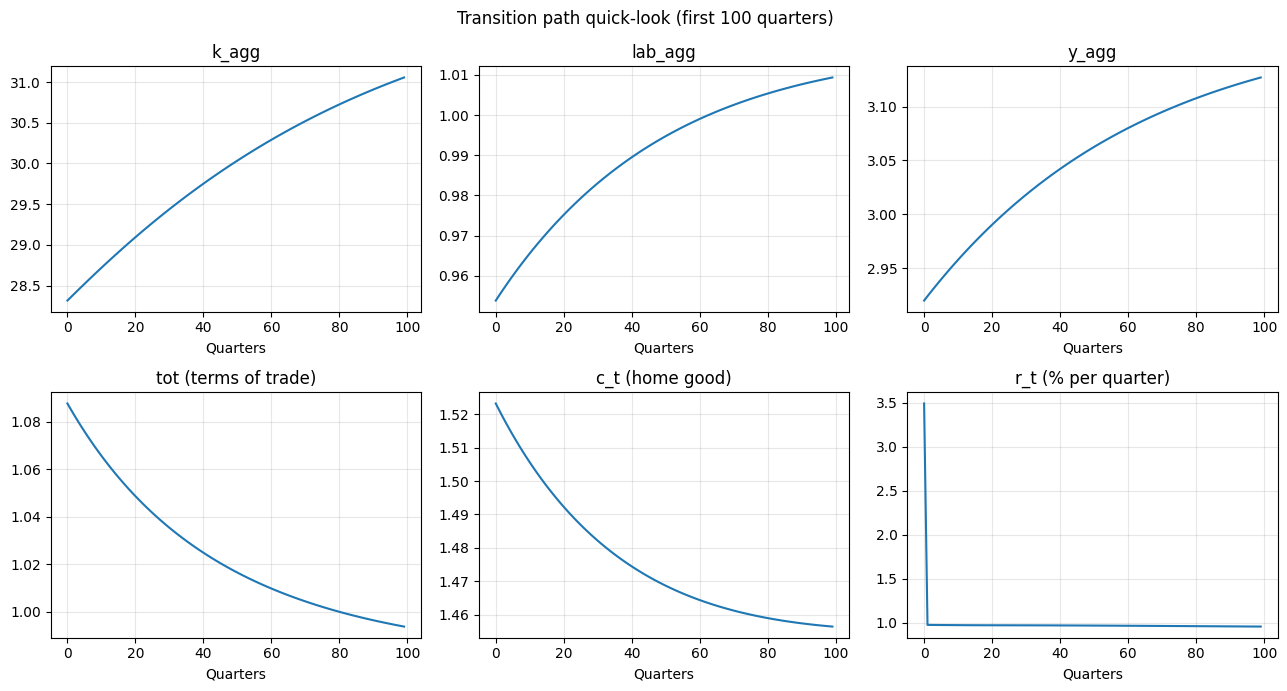

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
Tirf = 100
x = np.arange(Tirf)
axes[0, 0].plot(x, out['k_agg'][:Tirf]); axes[0, 0].set_title('k_agg')
axes[0, 1].plot(x, out['lab_agg'][:Tirf]); axes[0, 1].set_title('lab_agg')
axes[0, 2].plot(x, out['y_agg'][:Tirf]); axes[0, 2].set_title('y_agg')
axes[1, 0].plot(x, out['tot'][:Tirf]); axes[1, 0].set_title('tot (terms of trade)')
axes[1, 1].plot(x, out['c_t'][:Tirf]); axes[1, 1].set_title('c_t (home good)')
axes[1, 2].plot(x, 100 * out['r_t'][:Tirf]); axes[1, 2].set_title('r_t (% per quarter)')
for ax in axes.flat:
    ax.grid(True, alpha=0.3); ax.set_xlabel('Quarters')
fig.suptitle('Transition path quick-look (first 100 quarters)')
fig.tight_layout()
plt.show()

## Step 4 — save outputs for notebook 11

In [8]:
shock_start_idx = 40   # MATLAB shock_start_t = 41 (1-indexed)
dist_at_shock_start = out['dist_tran'][:, :, shock_start_idx].copy()

out_path = OUTPUT_DIR / 'transition_flex.npz'
np.savez(
    out_path,
    XX_star=XX_star,
    resid_star=resid_star,
    refined=REFINE,
    k_agg=out['k_agg'],
    lab_agg=out['lab_agg'],
    y_agg=out['y_agg'],
    tot=out['tot'],
    c_t=out['c_t'],
    c_t_agg=out['c_t_agg'],
    r_t=out['r_t'],
    r_k=out['r_k'],
    w_r=out['w_r'],
    q_agg=out['q_agg'],
    a_prime=out['a_prime'],
    a_t_agg=out['a_t_agg'],
    Profits=out['Profits'],
    Profits_i=out['Profits_i'],
    Profits_firms=out['Profits_firms'],
    net_c=out['net_c'],
    In_dis=out['In_dis'],
    dist_at_shock_start=dist_at_shock_start,
    shock_start_idx=shock_start_idx,
)
print(f'Saved: {out_path}')
print(f'  dist_at_shock_start: shape {dist_at_shock_start.shape}, sum = {dist_at_shock_start.sum():.6f}')

Saved: /Users/siyingli/github/de-Ferra2020-kz/Code/Python/output/transition_flex.npz
  dist_at_shock_start: shape (769, 7), sum = 1.000000


### Notes on Phase C / discrepancies (logged for `verification.md`)

* **Warm-start residual**: at MATLAB's `transition_start.mat`, $\|r\|_\infty \approx 1.2\times 10^{-4}$. This gap vs MATLAB's $10^{-6}$ tolerance is consistent with rounding accumulating across our 200-period backward EGM + forward simulation, plus differences in how `interp1(...,'pchip')` is implemented in scipy vs MATLAB. With `REFINE=True`, our `scipy.optimize.fsolve` polishes to $\sim 10^{-13}$, well below MATLAB's tolerance.
* **PCHIP interpolant**: MATLAB's `interp1(...,'pchip')` and `scipy.interpolate.PchipInterpolator` use the same shape-preserving cubic Hermite scheme but slightly different tie-breaking near grid endpoints. Differences are O($10^{-12}$) per interpolation call.
* **`bmin` clipping**: the MATLAB `keyboard` debug stop in `backsolve_egm.m` line 111 is replaced with a pure `RuntimeError`.
* **`ex_mean = 1`**: we exploit the normalisation `params.ex_mean=1` (Main.m line 59) to drop a divide-by-`ex_mean` from a few formulas — purely cosmetic, identical numerically.